# Estimation of Sales Revenue based on Advertisement Budgets across various channels

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# package versions used to verify to create a virtual environment:
# np.__version__
# # '2.3.4'
# pd.__version__
# # '2.3.3'
# matplotlib.__version__
# # '3.10.7'
# sns.__version__
# # '0.13.2'
# sklearn.__version__
# # '1.7.2'
# xgboost.__version__
# # '3.1.1'

In [3]:
# importing sales revenue data
adsales_df = pd.read_csv('data/advertising_and_sales_clean.csv')

adsales_df.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [4]:
# info about the df
adsales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4546 entries, 0 to 4545
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tv            4546 non-null   float64
 1   radio         4546 non-null   float64
 2   social_media  4546 non-null   float64
 3   influencer    4546 non-null   object 
 4   sales         4546 non-null   float64
dtypes: float64(4), object(1)
memory usage: 177.7+ KB


In [5]:
# stats of each col in df
adsales_df.describe(include='all')

,tv,radio,social_media,influencer,sales
count,4546.000000,4546.000000,4546.000000,4546,4546.000000
unique,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,Mega,NaN
freq,NaN,NaN,NaN,1152,NaN
mean,54062.912451,18157.533110,3323.472829,NaN,192413.332112
std,26104.941838,9663.259642,2211.253915,NaN,93019.873216
min,10000.000000,0.680000,0.030000,NaN,31199.410000
25%,32000.000000,10555.355000,1530.822500,NaN,112434.610000
50%,53000.000000,17859.515000,3055.565000,NaN,188963.680000
75%,77000.000000,25640.605000,4804.922500,NaN,272324.240000


In [6]:
# range of sales
min_sales = min(adsales_df['sales'])
max_sales = max(adsales_df['sales'])

print('Range of sales revenue:', min_sales, 'to', max_sales)


Range of sales revenue: 31199.41 to 364079.75


In [7]:
# shape of the initial dataframe
adsales_df.shape

(4546, 5)

## 1. Data Cleaning

In [8]:
# checking empty cells
adsales_df.isnull().sum()

tv              0
radio           0
social_media    0
influencer      0
sales           0
dtype: int64

In [9]:
# checking duplicate records
print('number of duplicate records:', int(adsales_df.duplicated().sum()))

number of duplicate records: 0


In [10]:
# name of the feature and target columns to check if it is in lowercase
list(adsales_df.columns)

['tv', 'radio', 'social_media', 'influencer', 'sales']

## 2. Exploratory Data Analysis EDA

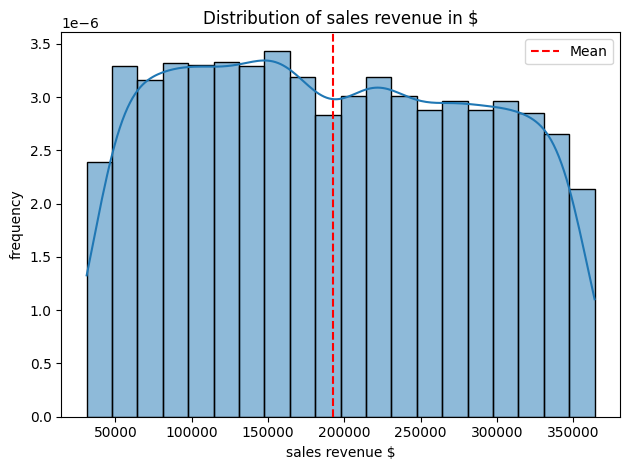

In [11]:
# distribution of the target variable --> sales revenue

# plotting the distribution
sns.histplot(adsales_df['sales'], bins=20, kde=True, stat='density', edgecolor='black')


plt.title('Distribution of sales revenue in $')
plt.xlabel('sales revenue $')
plt.ylabel('frequency')
plt.axvline(adsales_df['sales'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.tight_layout()

plt.show()

The target variable 'sales' revenue is almost uniformly distributed

In [12]:
# differentiating categorical and numerical features
# categorical features
cat_features  = list(adsales_df.select_dtypes(include=['object', 'category']).columns)

print('Categorical features:')
print(len(cat_features))
print(cat_features)
print()

# numerical features
num_features = list(adsales_df.select_dtypes(include=np.number).columns)

# removing the target
num_features.remove('sales') 

print('Numerical features:')
print(len(num_features))
print(num_features)

Categorical features:
1
['influencer']

Numerical features:
3
['tv', 'radio', 'social_media']


In [13]:
# unique values of categorical variable 'influencer'
print('Unique values of "influencer" feature: ')
print(adsales_df['influencer'].unique())
print(len(adsales_df['influencer'].unique()))

Unique values of "influencer" feature: 
['Mega' 'Micro' 'Nano' 'Macro']
4


Influencer categorized tiers explained:
<br><br>
Mega	1M+ followers <br>
Macro	100K–1M followers <br>
Micro	10K–100K followers <br>
Nano	1K–10K followers

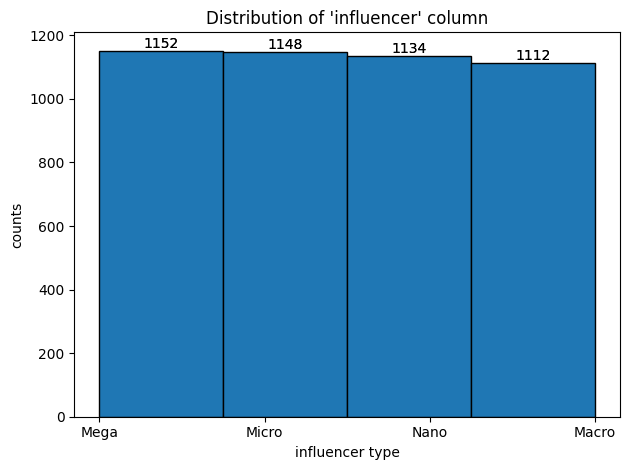

In [14]:
# distribution of the categorical feature 'influecer'
counts, bins, patches = plt.hist(adsales_df["influencer"], 
                                 bins=len(adsales_df["influencer"].unique()), 
                                 edgecolor='black')

# Count labels on bars
plt.bar_label(patches)

plt.title('Distribution of \'influencer\' column')
plt.xlabel('influencer type')
plt.ylabel('counts')

# Additional text labels (optional, since bar_label already shows counts)
for count, x in zip(counts, bins):
    if count > 0:
        plt.text(x + (bins[1]-bins[0])/2, count, str(int(count)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [15]:
adsales_df['influencer'].value_counts()

influencer
Mega     1152
Micro    1148
Nano     1134
Macro    1112
Name: count, dtype: int64

The 'influencer' categorical feature is almost balanced

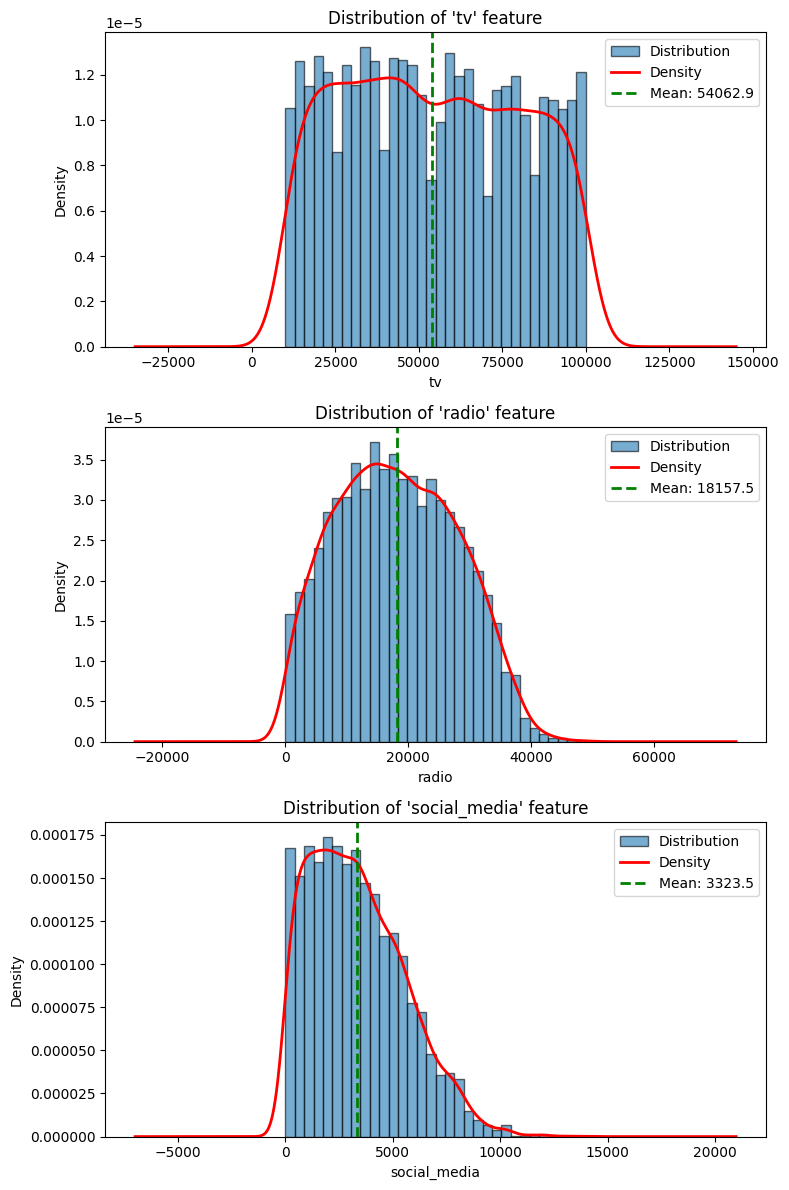

In [16]:
# distribution of all numerical features

# setting the plots
fig, axes = plt.subplots(3, 1, figsize=(8, 12))
axes = axes.flatten()

# plot each num feature
for i, col in enumerate(num_features):
    # Histogram with density
    axes[i].hist(adsales_df[col], bins=32, density=True, alpha=0.6, edgecolor='black', label='Distribution')
    
    # Density line (KDE)
    adsales_df[col].plot(kind='density', ax=axes[i], color='red', linewidth=2, label='Density')
    
    # Mean line
    mean_val = adsales_df[col].mean()
    axes[i].axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    
    axes[i].set_title(f'Distribution of \'{col}\' feature')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

Based on the distributions observed, even though there is a slight skew in 'social_media' and the platykurtic other 2 features, there is no need for any transformations on the give dataset

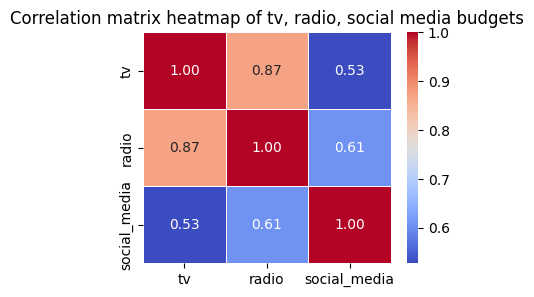

In [17]:
# correlation matrix of numerical features (between the num features)
corr_matrix = adsales_df[num_features].corr()

# Plotting the heatmap
plt.figure(figsize=(4,3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation matrix heatmap of tv, radio, social media budgets')
plt.show()

In [18]:
display(corr_matrix)

,tv,radio,social_media
tv,1.000000,0.869158,0.527687
radio,0.869158,1.000000,0.606338
social_media,0.527687,0.606338,1.000000


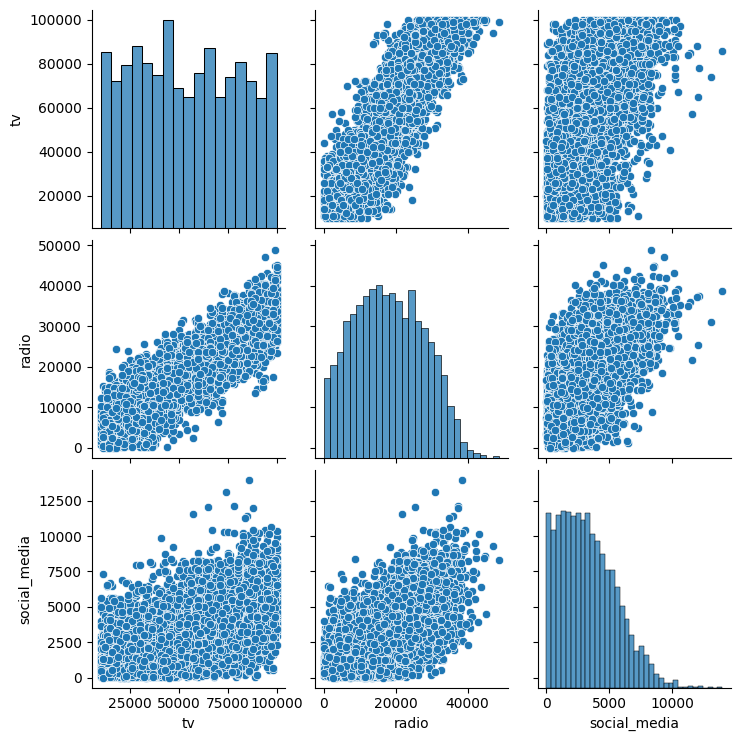

In [19]:
# pairplot of the numerical features in the advertisement budgets
sns.pairplot(adsales_df[num_features])
plt.show()

There is a high collinearity between tv and radio budgets. 

We can also observe the multicollinearity between all 3 numerical features

In [20]:
# mutual information of features against sales revenue (between features and target)
from sklearn.feature_selection import mutual_info_regression

# data prep for mi calc
mi_features = adsales_df.copy()
mi_features = mi_features.drop(columns='sales')
mi_features['influencer'] = pd.Categorical(mi_features['influencer']).codes  
print()

mi_score = mutual_info_regression(mi_features, adsales_df['sales'], discrete_features=[3], random_state=67)
print('Mutual information scores of each feature against the target variable \'sales\' revenue:')
print(pd.Series(mi_score, index=mi_features.columns).sort_values(ascending=False))


Mutual information scores of each feature against the target variable 'sales' revenue:
tv              3.324581
radio           0.669879
social_media    0.142022
influencer      0.006023
dtype: float64


In [21]:
# feature importance of numerical features against sales revenue using pearson correlation
num_feature_corr_w_sales = adsales_df[num_features].corrwith(adsales_df['sales'])

num_feature_corr_w_sales.abs().sort_values(ascending=False)

tv              0.999497
radio           0.868638
social_media    0.527446
dtype: float64

**Decision about 'tv' and 'radio' being collinear and also having high mutual info score against sales revenue:**
<br><br>
The 'tv' outperforms other advertising channels and second comes 'radio'. 

But, 'tv' and 'radio' are heavily correlated between them and also has a strong positive correlation with target 'sales' revenue. Strikingly, the visualization in pairplot reveals a thickness of the data points which means a greater spread when radio v/s tv is plotted. Since, radio also remains as a good choice for local advertisements, the feature is decided to be kept.

Due to the multicollinearity observed, to avoid overfitting, models with regularization parameters are opted to be chosen to fit the data.

In more advanced scenarios to select features, variance inflation factor VIF or PCA can be used.
<br><br><br>

**Decision on keeping or discarding categorical variable 'influencer':**
<br><br>
Even though 'influencer' channel seems to be almost independent of predicting 'sales' revenue due to its mutual information score, it is kept and NOT discarded, since it is the only categorical variable available that can increase the complexity of the future operations. 

In practical cases, it can be discarded and instead values of budgets allocated for each category of influencer channel and their respective budgets can be included as separate features.

In [22]:
# extracting the  the last record for inference and saving it as a csv
display('Before saving inference record:',adsales_df.tail(3))

adsales_df.tail(1).to_csv('record_for_inference.csv', index=False)

# dropping the inference record
adsales_df = adsales_df.iloc[:-1]

display('After saving inference record:', adsales_df.tail(3))

'Before saving inference record:'

,tv,radio,social_media,influencer,sales
4543,44000.0,19800.07,5096.19,Micro,163631.46
4544,71000.0,17534.64,1940.87,Macro,253610.41
4545,42000.0,15966.69,5046.55,Micro,148202.41


'After saving inference record:'

,tv,radio,social_media,influencer,sales
4542,71000.0,20610.69,6545.57,Nano,249101.92
4543,44000.0,19800.07,5096.19,Micro,163631.46
4544,71000.0,17534.64,1940.87,Macro,253610.41


In [23]:
# final dataframe and info about the dataframe for analyses
display(adsales_df.head())
print()
print(len(adsales_df.columns))
print(adsales_df.columns)
print()
print('Numerical features:', len(num_features))
print(num_features)
print()
print('Categorical features:', len(cat_features))
print(cat_features)
print()
print('Total records -->', adsales_df.shape[0])

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18



5
Index(['tv', 'radio', 'social_media', 'influencer', 'sales'], dtype='object')

Numerical features: 3
['tv', 'radio', 'social_media']

Categorical features: 1
['influencer']

Total records --> 4545


Finalized 4 features (3 numerical and 1 categorical) & 1 numerical target variable

## 3. Data preparation for modeling:

In [24]:
# splitting train, validation, test 60%, 20%, 20% sets
from sklearn.model_selection import train_test_split

full_train_df, test_df = train_test_split(adsales_df, test_size=0.2, random_state=67)

train_df, val_df = train_test_split(full_train_df, test_size=0.25, random_state=67)

# are the splits done right?
print(len(train_df), len(val_df), len(test_df))
print(round(len(train_df)/len(adsales_df), 2), round(len(val_df)/len(adsales_df), 2), round(len(test_df)/len(adsales_df), 2))

2727 909 909
0.6 0.2 0.2


In [25]:
# resetting indices of split train val test sets
full_train_df = full_train_df.reset_index(drop=True)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [26]:
# isolating the target variable sales revenue
y_full_train = full_train_df['sales'].values
y_train = train_df['sales'].values
y_val = val_df['sales'].values
y_test = test_df['sales'].values

In [27]:
# removing target from train val test feature sets
del full_train_df['sales']
del train_df['sales']
del val_df['sales']
del test_df['sales']

In [28]:
# importing dict vectorizer
from sklearn.feature_extraction import DictVectorizer

In [29]:
# fn to vectorize dataframes
def vectorize_dfs(train_or_full_df, val_or_test_df):
    
    # instantiate the dictionary vectorizer
    dictionary_vectorizer = DictVectorizer(sparse=False)
    
    # create x train or full train after converting the features to dictionary and vectorizing features
    X_train_or_full = dictionary_vectorizer.fit_transform(train_or_full_df[num_features + cat_features].to_dict(orient='records'))
    
    # transform the val or test set features by converting them to py dict and applying the transformation
    X_val_or_test = dictionary_vectorizer.transform(val_or_test_df[num_features + cat_features].to_dict(orient='records'))
    
    # extract feature names
    feature_names = dictionary_vectorizer.get_feature_names_out()
    
    print('Vectorizing successful!')

    return X_train_or_full, X_val_or_test, feature_names

In [30]:
# vectorizing features of train and validation 
X_train, X_val, feature_names_train = vectorize_dfs(train_df, val_df)

# vectorizing features of full train and test 
X_full_train, X_test, feature_names_full_train = vectorize_dfs(full_train_df, test_df)

Vectorizing successful!
Vectorizing successful!


In [31]:
# checking the first vectors of train, val, test feature sets 
print(X_train[:1])
print()
print(X_val[:1])
print()
print()
print(X_full_train[:1])
print()
print(X_test[:1])

[[0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00 2.104642e+04
  4.585300e+03 7.900000e+04]]

[[0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00 1.779116e+04
  8.784300e+02 6.200000e+04]]


[[0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 8.67441e+03 2.76025e+03
  1.20000e+04]]

[[0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 3.35767e+04 2.99085e+03
  7.90000e+04]]


## 4. Training the models

In [32]:
# importing the needed regressor model frameworks 
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

In [34]:
# constructing pipelines for each model
pipelines = {
    'ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(random_state=67))
    ]),
    'elastic_net': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(random_state=67))
    ]),
    'random_forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(random_state=67))
    ]),
    'gradient_boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingRegressor(random_state=67))
    ])
}

In [35]:
# constructing hyperparameter grids for tuning
param_grids = {
    'ridge': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0]
    },
    'elastic_net': {
        'model__alpha': [0.1, 1.0, 10.0],
        'model__l1_ratio': [0.2, 0.5, 0.8]
    },
    'random_forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    'gradient_boosting': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 4, 5]
    }
}

In [36]:
# 5 fold KFold for regression
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=67)

# custom fn to train and tune models using the training data
def train_and_tune_regression(pipelines, param_grids, X_train_or_full, y_train_or_full):
    """Train regression models with GridSearchCV and return the best estimators."""
    
    best_estimators = {}
    
    for name in pipelines:
        print(f"Training and tuning {name}...")
        
        # grid search hyperparameter tuning using negative mean sq error making -mse the scoring and deciding metric  
        grid = GridSearchCV(estimator=pipelines[name], param_grid=param_grids[name], cv=cv_splitter, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
        
        # fitting the data
        grid.fit(X_train_or_full, y_train_or_full)
        
        # extracting the best params
        print(f"Best params for {name}: {grid.best_params_}")
        
        # extracting the best estimator
        best_estimators[name] = grid.best_estimator_
        print("-" * 75)
        
    return best_estimators

In [37]:

best_reg_model_params = train_and_tune_regression(pipelines, param_grids, X_train, y_train)

Training and tuning ridge...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params for ridge: {'model__alpha': 0.1}
---------------------------------------------------------------------------
Training and tuning elastic_net...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params for elastic_net: {'model__alpha': 0.1, 'model__l1_ratio': 0.8}
---------------------------------------------------------------------------
Training and tuning random_forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params for random_forest: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
---------------------------------------------------------------------------
Training and tuning gradient_boosting...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params for gradient_boosting: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
-------------------------------------

In [38]:
# the complete model parameters of regularized and tuned models
best_reg_model_params

{'ridge': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', Ridge(alpha=0.1, random_state=67))]),
 'elastic_net': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  ElasticNet(alpha=0.1, l1_ratio=0.8, random_state=67))]),
 'random_forest': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  RandomForestRegressor(max_depth=10, min_samples_split=5,
                                        n_estimators=200, random_state=67))]),
 'gradient_boosting': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', GradientBoostingRegressor(random_state=67))])}

## 5. Predictions and evaluations

In [39]:
# custom fn to predict and evaluate and plot the eval metrics
def predict_and_evaluate_regression(best_model_reg_params, X_val_or_test, y_val_or_test):
    """Use best estimators to predict and print regression evaluation metrics."""
    
    # EVALUATION:
    
    # empty dict of lists to store metrics 
    scores = {name: [] for name in best_model_reg_params.keys()}
    
    # for adjusted R2
    n = len(y_val_or_test)
    p = X_val_or_test.shape[1]

    for name, model in best_model_reg_params.items():
        print(f"Evaluating model {name}...")
        y_pred = model.predict(X_val_or_test)

        # calculate eval metrics
        r2 = r2_score(y_val_or_test, y_pred)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        rmse = root_mean_squared_error(y_val_or_test, y_pred)
        mae = mean_absolute_error(y_val_or_test, y_pred)

        # storing the scores
        scores[name] = [r2, adj_r2, rmse, mae]

        print(f"R2 Score: {r2:.4f}")
        print(f"Adj R2: {adj_r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print("-" * 50)

    # VISUALIZATION:
    model_names = list(scores.keys())
    metric_values = np.array(list(scores.values()))  # shape: [n_models, 4]
    indices = np.arange(len(model_names))
    bar_width = 0.5

    # Create subplots (2x2 grid)
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Regression Model Comparison Across Metrics', fontsize=14)

    metric_titles = ['R² Score', 'Adjusted R²', 'RMSE', 'MAE']
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for i, ax in enumerate(axs.flat):
        ax.bar(indices, metric_values[:, i], color=colors[i], width=bar_width)
        ax.set_title(metric_titles[i])
        ax.set_xticks(indices)
        ax.set_xticklabels(model_names, rotation=30, ha='right')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # annotate bar labels
        for idx, val in enumerate(metric_values[:, i]):
            ax.text(idx, val + 0.01 * np.max(metric_values[:, i]), f'{val:.3f}',
                    ha='center', va='bottom', fontsize=8)

        # adjust y-label based on metric type
        if i in [0, 1]:
            ax.set_ylabel('Score')
        else:
            ax.set_ylabel('Error')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    return scores
    

Evaluating model ridge...
R2 Score: 0.9990
Adj R2: 0.9990
RMSE: 2903.2884
MAE: 2309.4136
--------------------------------------------------
Evaluating model elastic_net...
R2 Score: 0.9978
Adj R2: 0.9978
RMSE: 4362.9591
MAE: 3499.5225
--------------------------------------------------
Evaluating model random_forest...
R2 Score: 0.9988
Adj R2: 0.9988
RMSE: 3221.0856
MAE: 2557.2517
--------------------------------------------------
Evaluating model gradient_boosting...
R2 Score: 0.9990
Adj R2: 0.9990
RMSE: 2982.2223
MAE: 2361.6476
--------------------------------------------------


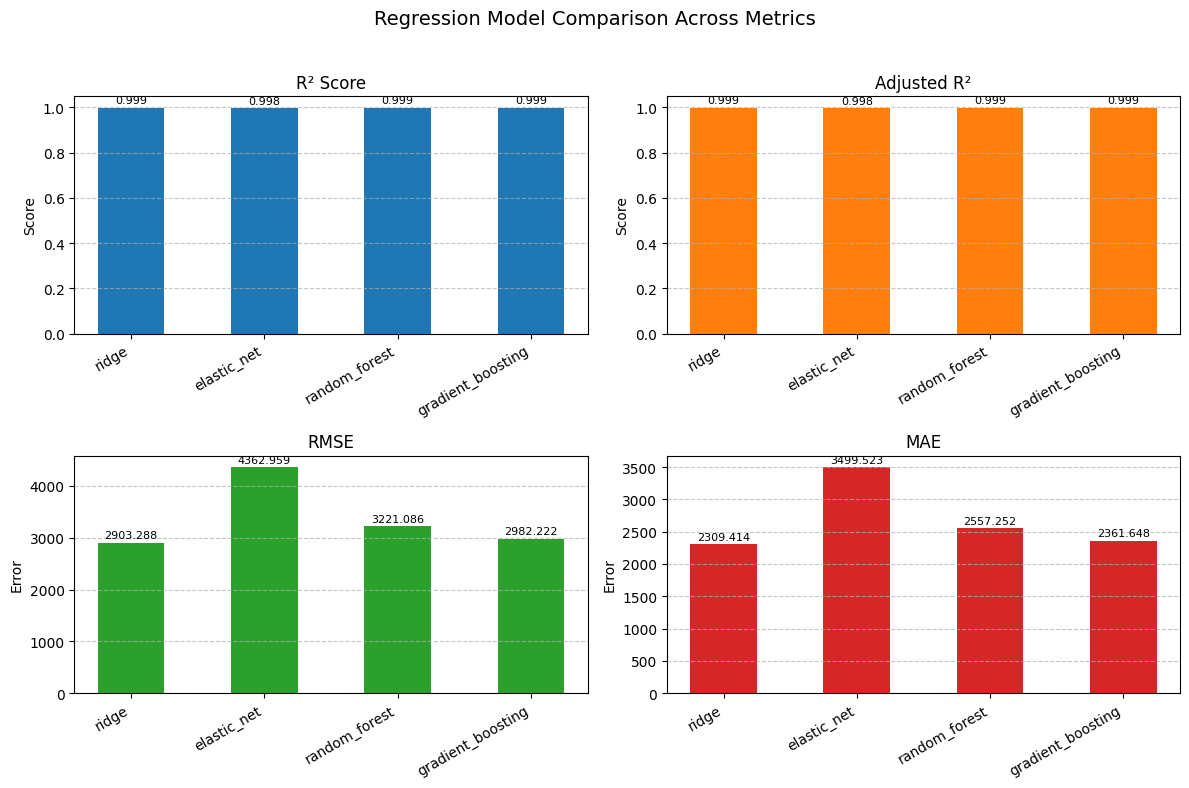

In [40]:
# making the prediction and retrieving the scores on validation dataset
val_set_scores = predict_and_evaluate_regression(best_reg_model_params, X_val, y_val)

### Final model rankings (production ready)

| Rank | Regression Model          | RMSE   | MAE    | R²     | Verdict                  |
|------|----------------|--------|--------|--------|--------------------------|
| 🥇   | **Ridge**      | **2,903** | **2,309** | **0.9990** | **Simplest + Interpretable** |
| 🥈   | **Gradient Boost**         | 2,982 | 2,362 | 0.9990 | Second best + robust     |
| 🥉   | **Random Forest**         | 3,221  | 2,557  | 0.9988    | Solid tree ensemble      |
| 4th  | **Elastic Net**    | 4,363  | 3,500  | 0.9978    | Still good, but beaten  |

**Reasons for selecting Ridge regression model for production:**
1. the Ridge regression outperforms other models across all metrics 
2. the coefficients of Ridge are much simpler to interpret
3. the model itself is lightweight and can be hosted efficiently